In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [24]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from statsmodels.tsa.arima.model import ARIMA

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

# Show first 5 rows
#print(df.head())
print('Shape:', df.shape)
print('\nColumns:', df.columns)
df.head()


Shape: (2640, 12)

Columns: Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [25]:
#EDA
print('Data Types & Nulls')
print(df.info())
print('\n Missing Values ')
print(df.isnull().sum())
print('\n Descriptive Statistics ')
df.describe()



Data Types & Nulls
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

 Missing Values 
Year                    0
Month                   0
Region               

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


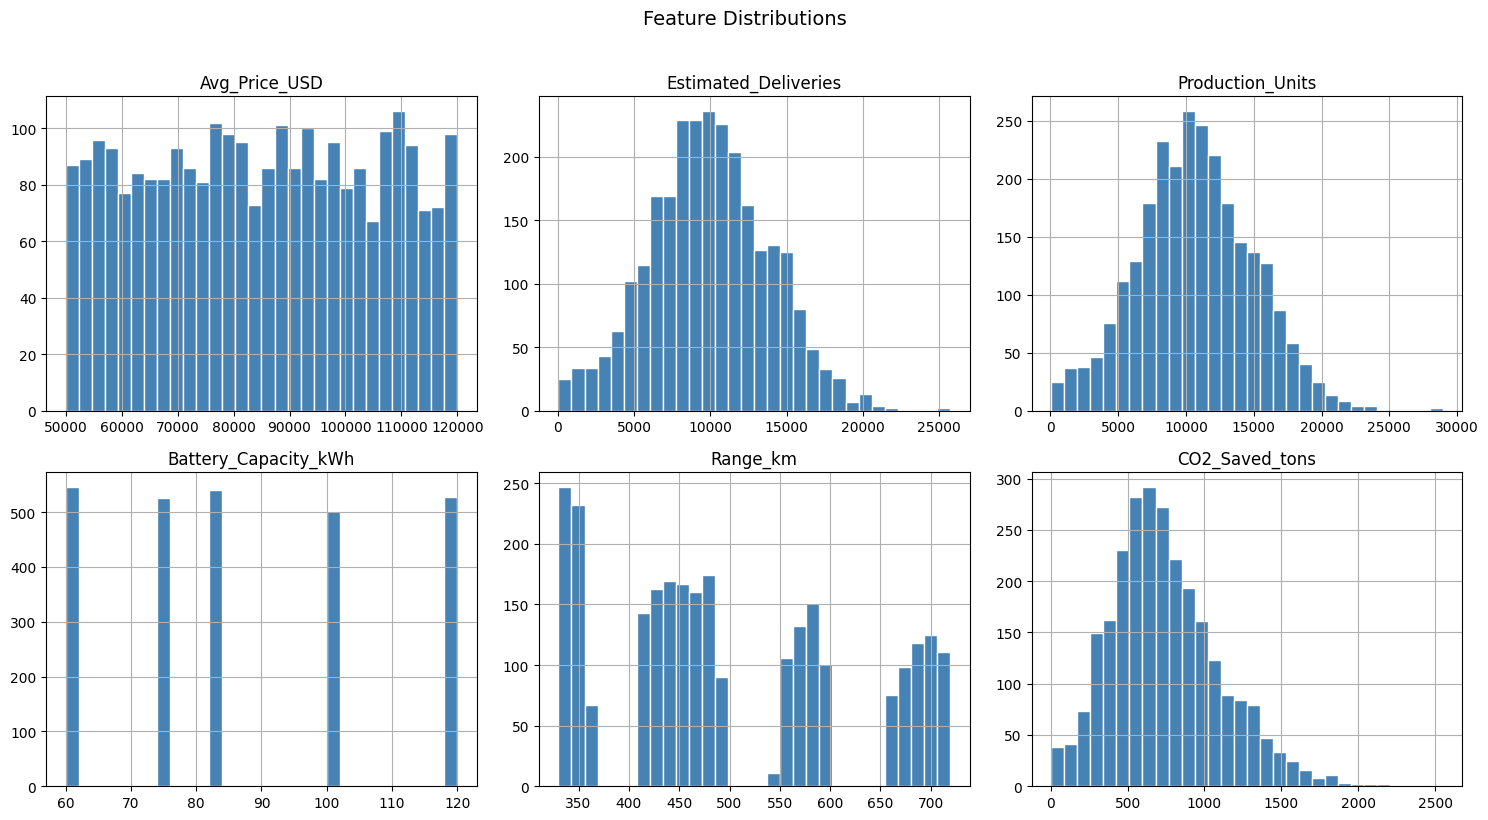

In [26]:
#Distribution of key numeric columns
num_cols = ['Avg_Price_USD', 'Estimated_Deliveries', 'Production_Units',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

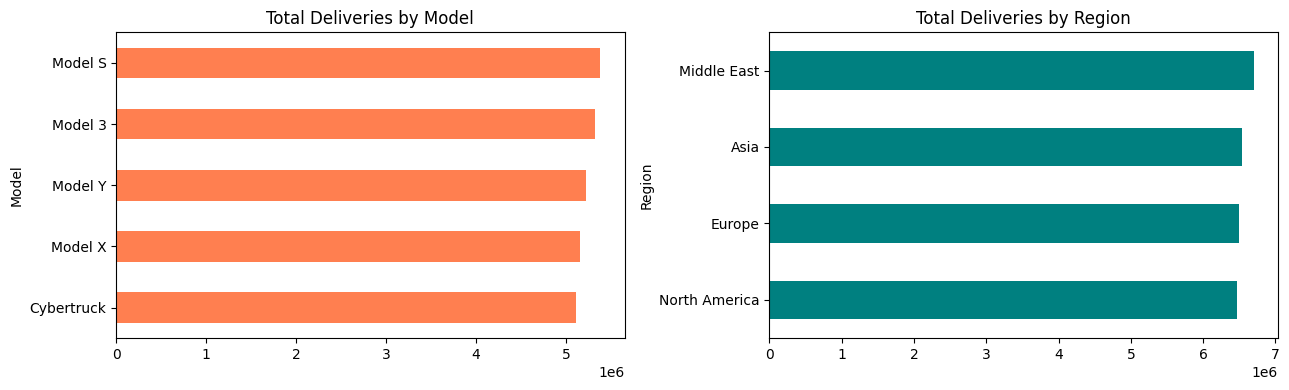

In [27]:
# Categorical Analysis 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.groupby('Model')['Estimated_Deliveries'].sum().sort_values().plot(
    kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Total Deliveries by Model')

df.groupby('Region')['Estimated_Deliveries'].sum().sort_values().plot(
    kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Total Deliveries by Region')

plt.tight_layout()
plt.show()

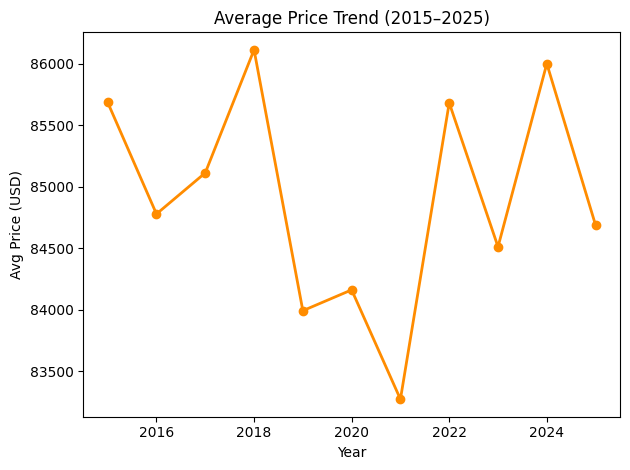

In [28]:
#Price trend over year
price_trend = df.groupby('Year')['Avg_Price_USD'].mean()
price_trend.plot(marker='o', color='darkorange', linewidth=2)
plt.title('Average Price Trend (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Avg Price (USD)')
plt.tight_layout()
plt.show()

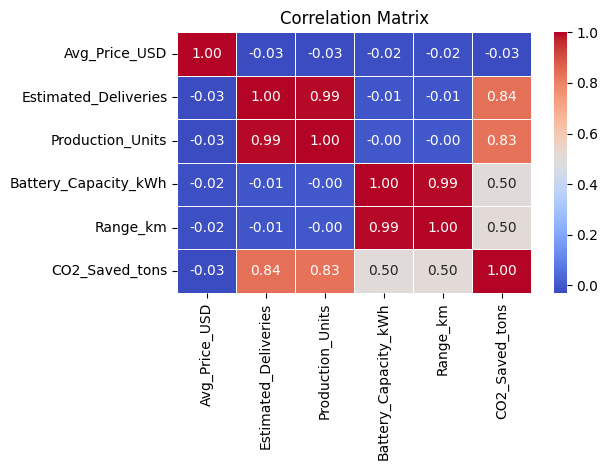

In [29]:
#Correlation Heatmap
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

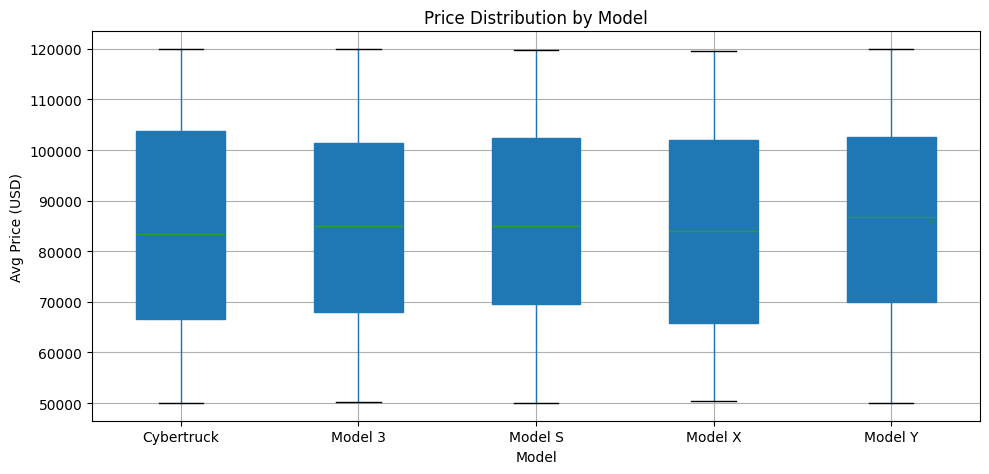

In [30]:
# Price by Model Boxplot 
df.boxplot(column='Avg_Price_USD', by='Model', figsize=(10, 5),
           patch_artist=True)
plt.suptitle('')
plt.title('Price Distribution by Model')
plt.ylabel('Avg Price (USD)')
plt.tight_layout()
plt.show()

In [31]:
#PREPROCESSING
# Handle Missing Values 
print('Missing values before:', df.isnull().sum().sum())

# Fill numeric nulls with median (
for col in df.select_dtypes(include='number').columns:
    df[col]=df[col].fillna(df[col].median())

# Fill categorical nulls with mode
for col in df.select_dtypes(include='object').columns:
    df[col]=df[col].fillna(df[col].mode()[0])

print('Missing values after:', df.isnull().sum().sum())

Missing values before: 0
Missing values after: 0


In [32]:
# Outlier Detection & Capping (IQR method)
def cap_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return series.clip(lower=lo, upper=hi)

for col in ['Avg_Price_USD', 'Estimated_Deliveries', 'CO2_Saved_tons']:
    df[col] = cap_outliers(df[col])

print('Outliers capped for: Avg_Price_USD, Estimated_Deliveries, CO2_Saved_tons')

Outliers capped for: Avg_Price_USD, Estimated_Deliveries, CO2_Saved_tons


In [33]:
#Encode Categoricals 
le_model  = LabelEncoder()
le_region = LabelEncoder()

df['Model_enc']  = le_model.fit_transform(df['Model'])
df['Region_enc'] = le_region.fit_transform(df['Region'])

print('Model mapping: ', dict(zip(le_model.classes_, le_model.transform(le_model.classes_))))
print('Region mapping:', dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))

Model mapping:  {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}
Region mapping: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}


In [34]:
#FEATURE ENGINEERING
#New derived features

# 1. Production efficiency  (deliveries / production)
df['Delivery_Efficiency'] = df['Estimated_Deliveries'] / (df['Production_Units'] + 1)

# 2. Price per km of range
df['Price_Per_km'] = df['Avg_Price_USD'] / (df['Range_km'] + 1)

# 3. CO2 savings per delivery
df['CO2_Per_Delivery'] = df['CO2_Saved_tons'] / (df['Estimated_Deliveries'] + 1)

# 4. Charging infrastructure density
df['Stations_Per_Delivery'] = df['Charging_Stations'] / (df['Estimated_Deliveries'] + 1)

# 5. Time index (year-fraction)
df['Time_Index'] = df['Year'] + (df['Month'] - 1) / 12

# 6. Is second half of year
df['H2_Flag'] = (df['Month'] >= 7).astype(int)

print('New features added:')
new_feats = ['Delivery_Efficiency','Price_Per_km','CO2_Per_Delivery',
             'Stations_Per_Delivery','Time_Index','H2_Flag']
df[new_feats].describe()

New features added:


,Delivery_Efficiency,Price_Per_km,CO2_Per_Delivery,Stations_Per_Delivery,Time_Index,H2_Flag
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,0.932228,179.643378,0.074871,1.472878,2020.458333,0.500000
std,0.037820,61.686816,0.017934,6.059524,3.175937,0.500095
min,0.702751,69.804993,0.049342,0.167797,2015.000000,0.000000
25%,0.899651,132.327904,0.062696,0.597254,2017.729167,0.000000
50%,0.932071,169.968189,0.070494,0.899383,2020.458333,0.500000
75%,0.964004,218.619245,0.087737,1.347397,2023.187500,1.000000
max,0.999911,358.298589,0.107843,225.918367,2025.916667,1.000000


In [35]:
#REGRESSION MODEL
#  Feature matrix & target 
FEATURES = [
    'Year', 'Month','Model_enc', 'Region_enc',
    'Production_Units', 'Battery_Capacity_kWh', 'Range_km',
    'CO2_Saved_tons', 'Charging_Stations',
    'Delivery_Efficiency', 'Price_Per_km',
    'CO2_Per_Delivery', 'Stations_Per_Delivery',
    'Time_Index', 'H2_Flag'
]
TARGET = 'Avg_Price_USD'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (2112, 15) | Test: (528, 15)


In [36]:
# Train all three models 
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{name:20s}  RMSE={rmse:>10.2f}  MAE={mae:>10.2f}  R²={r2:.4f}')
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'Lasso Regression' : Lasso(alpha=1.0, max_iter=5000),
}

results = []
trained = {}
print(f'{"Model":20s}  {"RMSE":>12s}  {"MAE":>12s}  R²')
print('-' * 60)
for name, mdl in models.items():
    mdl.fit(X_train_sc, y_train)
    preds = mdl.predict(X_test_sc)
    results.append(evaluate(name, y_test, preds))
    trained[name] = mdl

Model                         RMSE           MAE  R²
------------------------------------------------------------
Linear Regression     RMSE=   6139.73  MAE=   4996.35  R²=0.9000
Ridge Regression      RMSE=   6140.62  MAE=   4996.06  R²=0.9000
Lasso Regression      RMSE=   6139.02  MAE=   4995.85  R²=0.9001


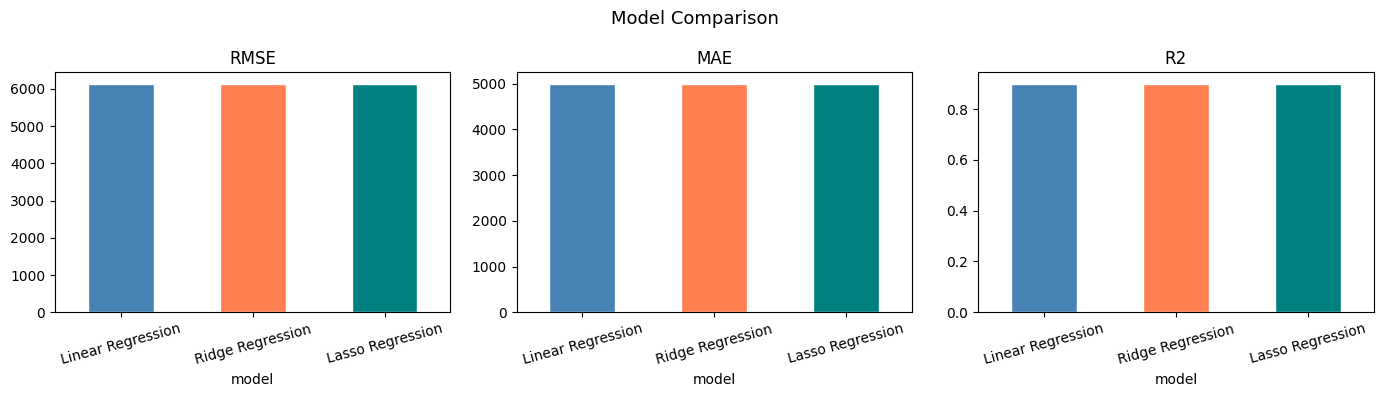

In [37]:
# Visual comparison 
res_df = pd.DataFrame(results).set_index('model')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    res_df[metric].plot(kind='bar', ax=ax, color=['steelblue','coral','teal'],
                        edgecolor='white', rot=15)
    ax.set_title(metric)
plt.suptitle('Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

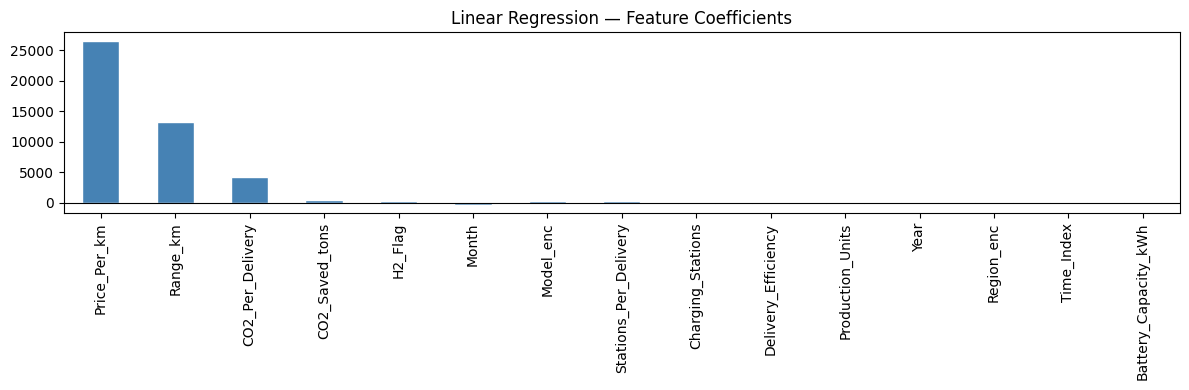

In [38]:
# Feature Coefficients (Linear Regression)
coef_df = pd.Series(
    trained['Linear Regression'].coef_,
    index=FEATURES
).sort_values(key=abs, ascending=False)

coef_df.plot(kind='bar', figsize=(12, 4), color='steelblue', edgecolor='white')
plt.title('Linear Regression — Feature Coefficients')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [40]:
# Ridge Hyperparameter Tuning
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

ridge_gs = GridSearchCV(
    Ridge(), ridge_params,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
ridge_gs.fit(X_train_sc, y_train)

print('Best Ridge alpha :', ridge_gs.best_params_)
print(f'Best CV RMSE     : {-ridge_gs.best_score_:.2f}')

Best Ridge alpha : {'alpha': 1}
Best CV RMSE     : 6394.08


In [43]:
# Lasso Hyperparameter Tuning
lasso_params = {
    'alpha': [0.1, 1, 10, 50, 100, 500]
}

lasso_gs = GridSearchCV(
    Lasso(max_iter=50000),
    lasso_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_gs.fit(X_train_sc, y_train)

print("Best Lasso alpha :", lasso_gs.best_params_)
print(f"Best CV RMSE     : {-lasso_gs.best_score_:.2f}")

Best Lasso alpha : {'alpha': 50}
Best CV RMSE     : 6387.56


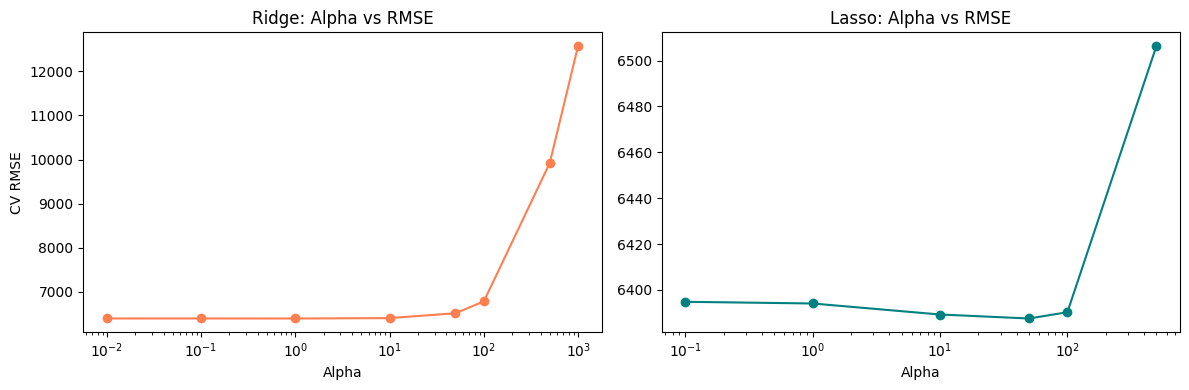

In [44]:
#Alpha vs RMSE Curve
ridge_cv = pd.DataFrame(ridge_gs.cv_results_)
lasso_cv = pd.DataFrame(lasso_gs.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ridge_cv['param_alpha'].astype(float),
             -ridge_cv['mean_test_score'], marker='o', color='coral')
axes[0].set_xscale('log')
axes[0].set_title('Ridge: Alpha vs RMSE')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('CV RMSE')

axes[1].plot(lasso_cv['param_alpha'].astype(float),
             -lasso_cv['mean_test_score'], marker='o', color='teal')
axes[1].set_xscale('log')
axes[1].set_title('Lasso: Alpha vs RMSE')
axes[1].set_xlabel('Alpha')

plt.tight_layout()
plt.show()

In [45]:
# Final evaluation with tuned models
print('=== Tuned Model Performance on Test Set ===')
print(f'{"Model":20s}  {"RMSE":>12s}  {"MAE":>12s}  R²')
print('-' * 60)

best_ridge = ridge_gs.best_estimator_
best_lasso = lasso_gs.best_estimator_

evaluate('Tuned Ridge', y_test, best_ridge.predict(X_test_sc))
evaluate('Tuned Lasso', y_test, best_lasso.predict(X_test_sc))

=== Tuned Model Performance on Test Set ===
Model                         RMSE           MAE  R²
------------------------------------------------------------
Tuned Ridge           RMSE=   6140.62  MAE=   4996.06  R²=0.9000
Tuned Lasso           RMSE=   6120.60  MAE=   4977.51  R²=0.9007


{'model': 'Tuned Lasso',
 'RMSE': np.float64(6120.6019156320635),
 'MAE': 4977.508248304374,
 'R2': 0.9006616211839986}

In [46]:
#  K-Fold Cross Validation (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Linear' : LinearRegression(),
    'Ridge'  : Ridge(alpha=ridge_gs.best_params_['alpha']),
    'Lasso'  : Lasso(alpha=lasso_gs.best_params_['alpha'], max_iter=10000),
}

# Use full scaled data for CV
X_sc_all = scaler.fit_transform(X)

cv_results = {}
print(f'{"Model":10s}  {"Mean R²":>10s}  {"Std R²":>10s}  {"Mean RMSE":>12s}')
print('-' * 55)
for name, mdl in cv_models.items():
    r2_scores   = cross_val_score(mdl, X_sc_all, y, cv=kf, scoring='r2')
    rmse_scores = np.sqrt(-cross_val_score(mdl, X_sc_all, y, cv=kf,
                                           scoring='neg_mean_squared_error'))
    cv_results[name] = r2_scores
    print(f'{name:10s}  {r2_scores.mean():>10.4f}  {r2_scores.std():>10.4f}  {rmse_scores.mean():>12.2f}')

Model          Mean R²      Std R²     Mean RMSE
-------------------------------------------------------
Linear          0.9006      0.0058       6332.89
Ridge           0.9006      0.0058       6332.78
Lasso           0.9008      0.0060       6325.36


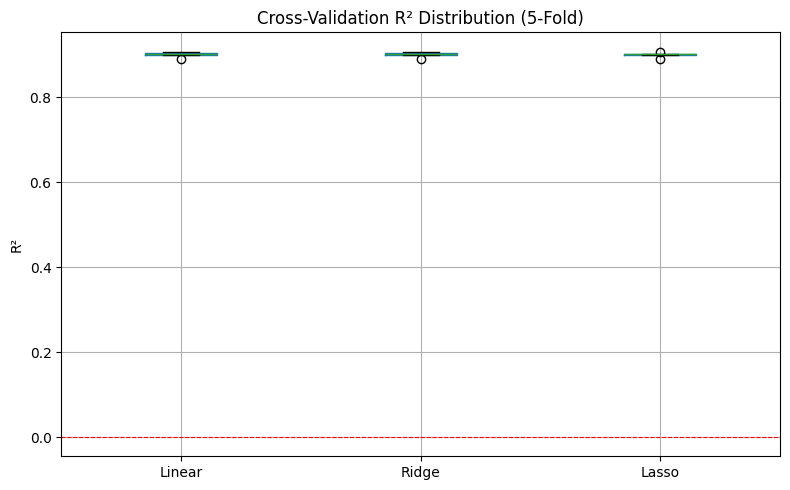

In [47]:
# CV R² Boxplot 
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(figsize=(8, 5))
plt.title('Cross-Validation R² Distribution (5-Fold)')
plt.ylabel('R²')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

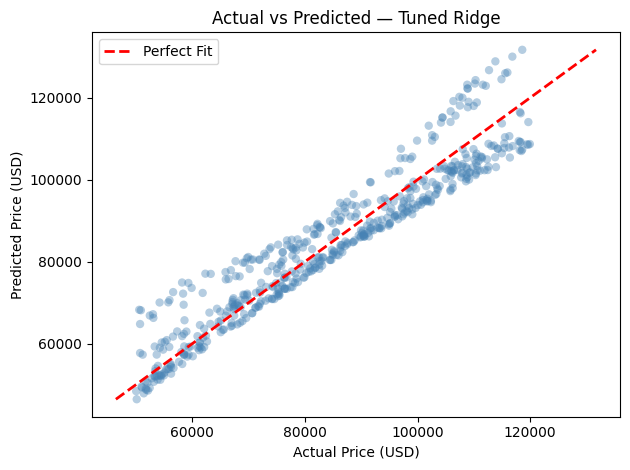

In [61]:
# Actual vs Predicted Scatter (Best Model) 
best_mdl = Ridge(alpha=ridge_gs.best_params_['alpha'])
best_mdl.fit(X_train_sc, y_train)
y_pred = best_mdl.predict(X_test_sc)

plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none')
min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted — Tuned Ridge')
plt.legend()
plt.tight_layout()
plt.show()

Time series range: 2015-01-01 → 2025-12-01
Total months     : 132


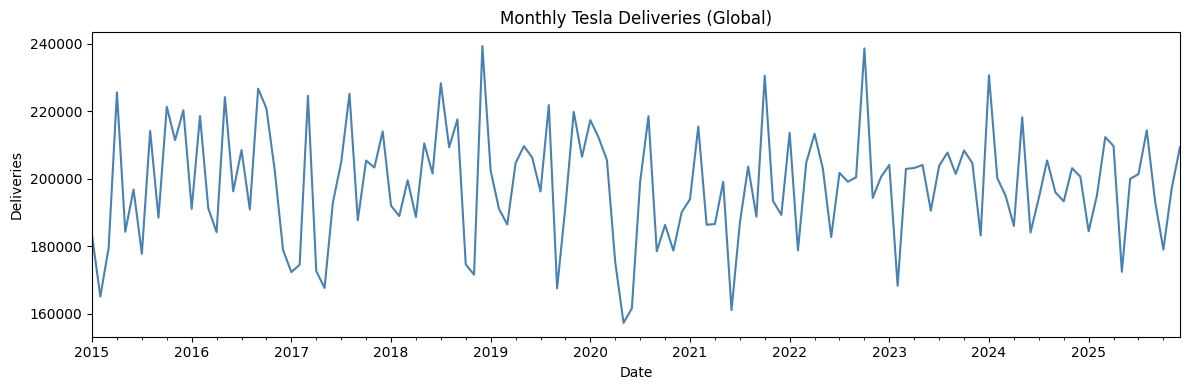

In [84]:
# ── Section 8: Time Series Forecasting ────────────────────────────────────
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# Aggregate global monthly deliveries
ts_df = (
    df.groupby(['Year', 'Month'])['Estimated_Deliveries']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Month'])
)
ts_df['Date'] = pd.to_datetime(
    ts_df['Year'].astype(str) + '-' +
    ts_df['Month'].astype(str).str.zfill(2) + '-01'
)
ts = ts_df.set_index('Date')['Estimated_Deliveries']

# Set monthly frequency explicitly (required by Holt-Winters)
ts = ts.asfreq('MS')

print('Time series range:', ts.index[0].date(), '→', ts.index[-1].date())
print('Total months     :', len(ts))

ts.plot(figsize=(12, 4), color='steelblue', linewidth=1.5)
plt.title('Monthly Tesla Deliveries (Global)')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()

In [87]:
# Train / Test split — hold out last 12 months
FORECAST_STEPS = 12
train_ts = ts.iloc[:-FORECAST_STEPS]
test_ts  = ts.iloc[-FORECAST_STEPS:]

print(f'Train: {len(train_ts)} months | Test: {len(test_ts)} months')

Train: 120 months | Test: 12 months


In [88]:
# 8A — Holt-Winters (additive trend + additive seasonality)
hw_model = ExponentialSmoothing(
    train_ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

hw_pred = hw_model.forecast(FORECAST_STEPS)
hw_pred.index = test_ts.index

hw_rmse = np.sqrt(mean_squared_error(test_ts, hw_pred))
hw_mae  = mean_absolute_error(test_ts, hw_pred)
print(f'Holt-Winters  RMSE : {hw_rmse:.2f}')
print(f'Holt-Winters  MAE  : {hw_mae:.2f}')

Holt-Winters  RMSE : 13918.74
Holt-Winters  MAE  : 10523.17


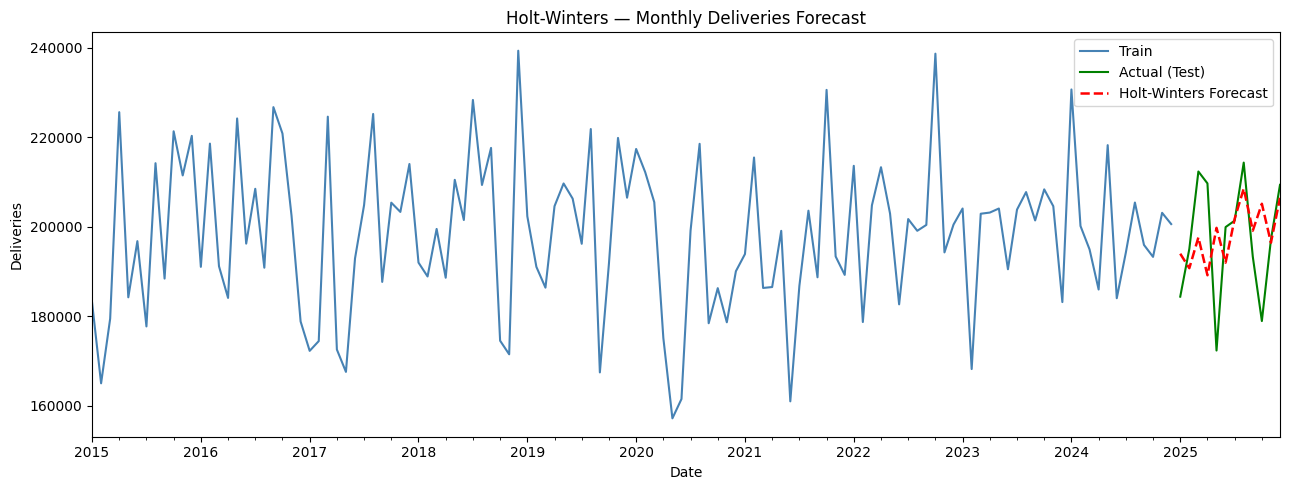

In [89]:
plt.figure(figsize=(13, 5))
train_ts.plot(label='Train', color='steelblue', linewidth=1.5)
test_ts.plot(label='Actual (Test)', color='green', linewidth=1.5)
hw_pred.plot(label='Holt-Winters Forecast', color='red',
             linestyle='--', linewidth=1.8)
plt.title('Holt-Winters — Monthly Deliveries Forecast')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
from prophet import Prophet

In [92]:
# Prepare Prophet input (requires columns: ds, y)
prophet_train = (
    train_ts
    .reset_index()
    .rename(columns={'Date': 'ds', 'Estimated_Deliveries': 'y'})
)

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
prophet_model.fit(prophet_train)

# Forecast 12 months
future_df  = prophet_model.make_future_dataframe(periods=FORECAST_STEPS, freq='MS')
prophet_fc = prophet_model.predict(future_df)

# Align predicted index to test index
prophet_pred = prophet_fc.set_index('ds')['yhat'].iloc[-FORECAST_STEPS:]
prophet_pred.index = test_ts.index

p_rmse = np.sqrt(mean_squared_error(test_ts, prophet_pred))
p_mae  = mean_absolute_error(test_ts, prophet_pred)
print(f'Prophet  RMSE : {p_rmse:.2f}')
print(f'Prophet  MAE  : {p_mae:.2f}')

08:53:02 - cmdstanpy - INFO - Chain [1] start processing
08:53:02 - cmdstanpy - INFO - Chain [1] done processing


Prophet  RMSE : 14147.35
Prophet  MAE  : 10916.67


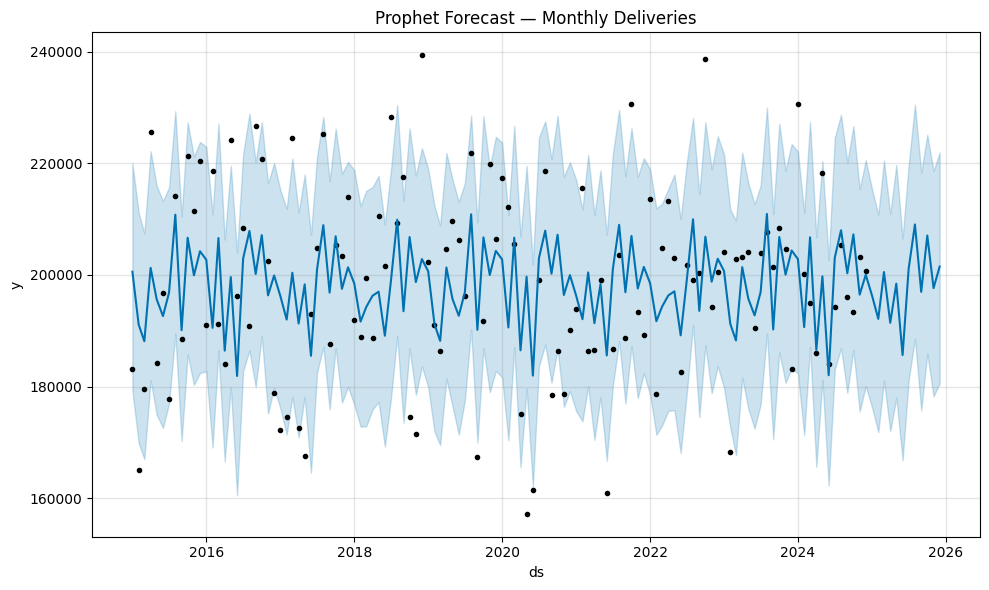

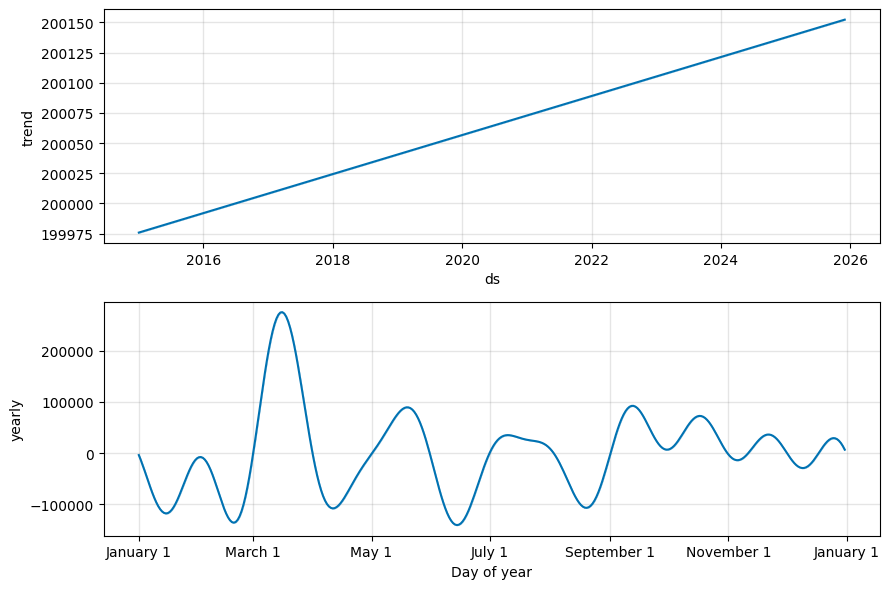

In [93]:
prophet_model.plot(prophet_fc)
plt.title('Prophet Forecast — Monthly Deliveries')
plt.tight_layout()
plt.show()

prophet_model.plot_components(prophet_fc)
plt.tight_layout()
plt.show()

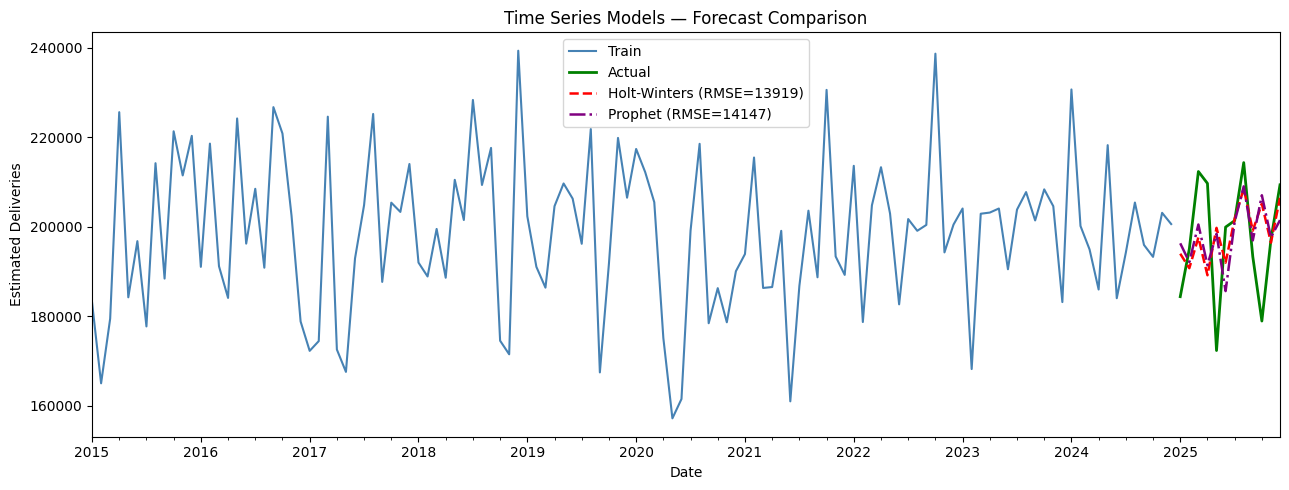

       Model         RMSE          MAE
Holt-Winters 13918.741072 10523.174031
     Prophet 14147.348918 10916.671787


In [94]:
# 8C — Model comparison on test window
plt.figure(figsize=(13, 5))
train_ts.plot(label='Train', color='steelblue', linewidth=1.5)
test_ts.plot(label='Actual', color='green', linewidth=2)
hw_pred.plot(label=f'Holt-Winters (RMSE={hw_rmse:.0f})',
             linestyle='--', color='red', linewidth=1.8)
prophet_pred.plot(label=f'Prophet (RMSE={p_rmse:.0f})',
                  linestyle='-.', color='purple', linewidth=1.8)
plt.title('Time Series Models — Forecast Comparison')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

metrics_ts = pd.DataFrame({
    'Model': ['Holt-Winters', 'Prophet'],
    'RMSE' : [hw_rmse, p_rmse],
    'MAE'  : [hw_mae,  p_mae],
})
print(metrics_ts.to_string(index=False))